### **Imports**

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
import torch
import time

/Users/dariushghassemieh/llms/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.set_verbosity_error()
logging.disable_progress_bar()

### **Set variables**

In [3]:
model_name = "gpt2"

query = ("I love school because it's very", 1, "hate", "question") # (phrase, index to morph, target word) 

In [4]:
gen_time = 0

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True)
embedding_layer = model.get_input_embeddings()

""" returns the embedding vector of a word W """
def get_word_embedding(W: str, leading_space=True) -> torch.Tensor:
    text = (" " + W) if leading_space else W
    ids = tokenizer.encode(text)
    if len(ids) != 1:
        toks = tokenizer.convert_ids_to_tokens(ids)
        print(f"  warning: {W!r} -> {len(ids)} tokens {toks}, using first")
    return embedding_layer.weight[ids[0]]

In [5]:
(phrase, changed_index, target_word_1, target_word_2) = query

In [ ]:
from collections import defaultdict

start_time = time.perf_counter()

inputs = tokenizer(phrase, return_tensors="pt")
attn = inputs["attention_mask"]
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("tokens:", list(enumerate(tokens)))

base_embeds = embedding_layer(inputs["input_ids"]).detach()
original_vec = base_embeds[0, changed_index, :].clone()
target_vec_1 = get_word_embedding(target_word_1)
target_vec_2 = get_word_embedding(target_word_2)

morph_word = tokenizer.decode(inputs["input_ids"][0][changed_index]).strip()

top_5_at_each_alpha = defaultdict(dict)
winners = set()

for i, alpha in enumerate(torch.linspace(0, 1, 26)):
    for j, beta in enumerate(torch.linspace(0, 1, 26)):
        embeds = base_embeds.clone()
        # barycentric blend: weights on (original, target_1, target_2) sum to 1.
        # true interpolation only inside the triangle alpha + beta <= 1;
        embeds[0, changed_index, :] = (
            (1 - alpha - beta) * original_vec
            + alpha * target_vec_1
            + beta * target_vec_2
        )
        with torch.no_grad():
            logits = model(inputs_embeds=embeds, attention_mask=attn).logits
        top5 = torch.topk(torch.softmax(logits[0, -1, :], dim=-1), 5)
        top_5_at_each_alpha[i][j] = top5
        winners.add(tokenizer.decode(top5.indices[0]).strip())

def decode_corner(i, j):
    return tokenizer.decode(top_5_at_each_alpha[i][j].indices[0]).strip()

def standalone_prediction(vec):
    e = base_embeds.clone()
    e[0, changed_index, :] = vec
    with torch.no_grad():
        lg = model(inputs_embeds=e, attention_mask=attn).logits
    return tokenizer.decode(torch.topk(lg[0, -1, :], 1).indices[0]).strip()

print("corners (expected word -> decoded top-1):")
print(f"  (0,0) original    {morph_word!r:>10} -> {decode_corner(0, 0)!r}")
print(f"  (1,0) target_1    {target_word_1!r:>10} -> {decode_corner(25, 0)!r}")
print(f"  (0,1) target_2    {target_word_2!r:>10} -> {decode_corner(0, 25)!r}")
print(f"  (1,1) extrapolation (invalid) -> {decode_corner(25, 25)!r}")

s1 = standalone_prediction(target_vec_1)
s2 = standalone_prediction(target_vec_2)
print(f"target_1 {target_word_1!r} standalone: {s1!r}  (1,0) match: {s1 == decode_corner(25, 0)}")
print(f"target_2 {target_word_2!r} standalone: {s2!r}  (0,1) match: {s2 == decode_corner(0, 25)}")
print(f"distinct top tokens across the grid: {sorted(winners)}")

tokens: [(0, 'I'), (1, 'Ġlove'), (2, 'Ġschool'), (3, 'Ġbecause'), (4, 'Ġit'), (5, "'s"), (6, 'Ġvery')]
corners (expected word -> decoded top-1):
  (0,0) original        'love' -> 'fun'
  (1,0) target_1        'hate' -> 'hard'
  (0,1) target_2    'question' -> 'hard'
  (1,1) extrapolation (invalid) -> 'hard'
target_1 'hate' standalone: 'hard'  (1,0) match: True
target_2 'question' standalone: 'hard'  (0,1) match: True
distinct top tokens across the grid: [',', 'fun', 'hard', 'important']


In [7]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## Now we can graph the results of interpolating "love" to "hate" and "question"

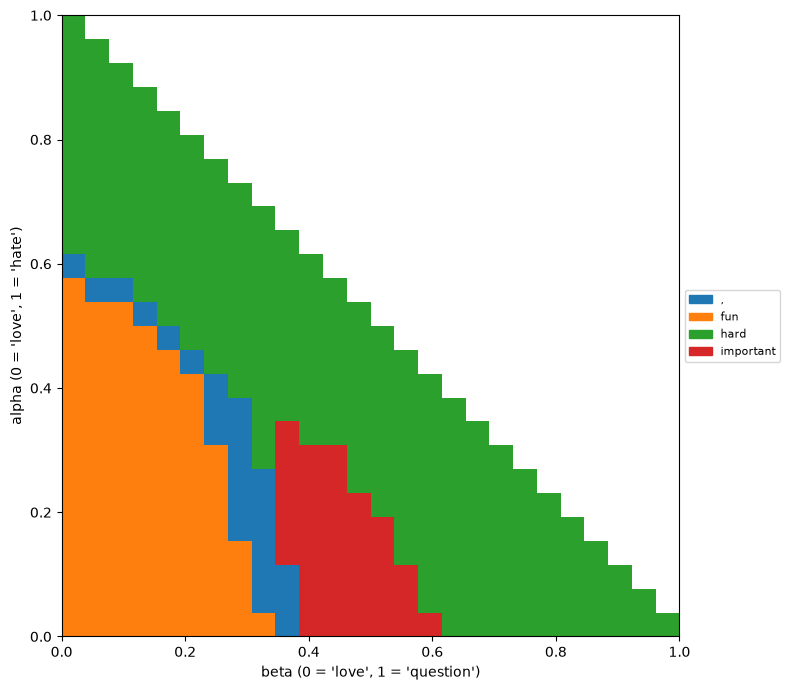

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

n = len(top_5_at_each_alpha)          # 26
grid = np.empty((n, n), dtype=int)    # winning token id at each (i, j)
for i in top_5_at_each_alpha:
    for j in top_5_at_each_alpha[i]:
        grid[i, j] = top_5_at_each_alpha[i][j].indices[0].item()

# map the distinct winners to contiguous integers so we can use a discrete colormap
winners = sorted(set(grid.ravel()))
remap = {tok: k for k, tok in enumerate(winners)}
idx_grid = np.vectorize(remap.get)(grid).astype(float)
words = [tokenizer.decode(t).strip().lower() for t in winners]

# valid interpolation only inside the triangle alpha + beta <= 1; mask the rest
A = np.linspace(0, 1, n)
B = np.linspace(0, 1, n)
BB, AA = np.meshgrid(B, A)
idx_grid = np.ma.masked_where(AA + BB > 1, idx_grid)

# color each region by its word name where possible, else a fallback color
fallback = iter(plt.get_cmap("tab10").colors)
def color_for(w):
    if w in mcolors.CSS4_COLORS:
        return "dimgray" if w == "black" else w
    return next(fallback)
colors = [color_for(w) for w in words]
cmap = mcolors.ListedColormap(colors)
cmap.set_bad(color="white")

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(idx_grid, origin="lower", extent=[0, 1, 0, 1],
          cmap=cmap, vmin=0, vmax=len(winners) - 1, aspect="auto",
          interpolation="nearest")

ax.set_xlabel(f"beta (0 = {morph_word!r}, 1 = {target_word_2!r})")
ax.set_ylabel(f"alpha (0 = {morph_word!r}, 1 = {target_word_1!r})")
ax.legend(handles=[Patch(color=c, label=w) for c, w in zip(colors, words)],
          loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
def top_5_dict_lookup(i, j, t):
    t5 = top_5_at_each_alpha[i][j]
    for p, idx in zip(t5.values, t5.indices):
        if idx.item() == t:
            return p.item()
    return 0.0

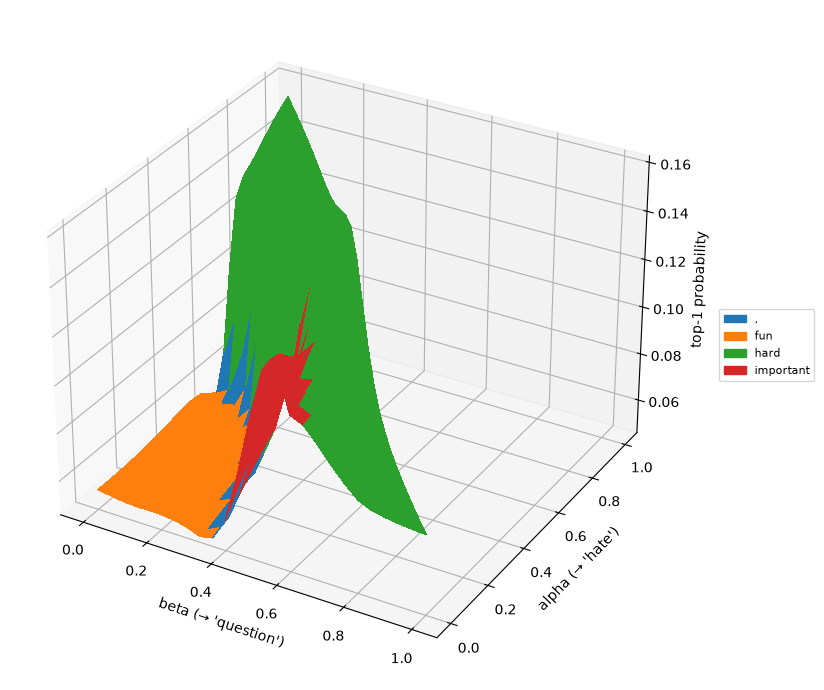

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

n = len(top_5_at_each_alpha)
A = np.linspace(0, 1, n)
B = np.linspace(0, 1, n)
BB, AA = np.meshgrid(B, A)        # AA varies down rows (alpha), BB across cols (beta)

Z   = np.empty((n, n))           # top-1 probability
win = np.empty((n, n), dtype=int)
for i in top_5_at_each_alpha:
    for j in top_5_at_each_alpha[i]:
        t5 = top_5_at_each_alpha[i][j]
        Z[i, j]   = t5.values[0].item()
        win[i, j] = t5.indices[0].item()

# valid interpolation only inside the triangle alpha + beta <= 1; NaN out the rest
Z = np.where(AA + BB > 1, np.nan, Z)

winners = sorted(set(win.ravel()))
remap = {t: k for k, t in enumerate(winners)}
words = [tokenizer.decode(t).strip().lower() for t in winners]

fallback = iter(plt.get_cmap("tab10").colors)
def color_for(w):
    if w in mcolors.CSS4_COLORS:
        return "dimgray" if w == "black" else w
    return next(fallback)
colors = [color_for(w) for w in words]
cmap = mcolors.ListedColormap(colors)

# color each facet by its winning token
facecolors = cmap(np.vectorize(remap.get)(win) / max(len(winners) - 1, 1))

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(BB, AA, Z, facecolors=facecolors,
                rstride=1, cstride=1, linewidth=0, antialiased=False, shade=False)

ax.set_xlabel(f"beta (→ {target_word_2!r})")
ax.set_ylabel(f"alpha (→ {target_word_1!r})")
ax.set_zlabel("top-1 probability")
ax.legend(handles=[Patch(color=c, label=w) for c, w in zip(colors, words)],
          loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=8)


plt.tight_layout()
plt.show()

In [11]:
%pip install plotly
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import plotly.graph_objects as go
import numpy as np

n = len(top_5_at_each_alpha)
A = np.linspace(0, 1, n)
B = np.linspace(0, 1, n)

Z = np.empty((n, n))
for i in top_5_at_each_alpha:
    for j in top_5_at_each_alpha[i]:
        Z[i, j] = top_5_at_each_alpha[i][j].values[0].item()

# valid interpolation only inside the triangle alpha + beta <= 1; NaN out the rest
BB, AA = np.meshgrid(B, A)
Z = np.where(AA + BB > 1, np.nan, Z)

fig = go.Figure(go.Surface(z=Z, x=B, y=A, colorscale="Viridis"))
fig.update_layout(
    scene=dict(
        xaxis_title=f"beta (→ {target_word_2!r})",
        yaxis_title=f"alpha (→ {target_word_1!r})",
        zaxis_title="top-1 probability",
    ),
    width=800, height=700,
)
fig.show()

In [ ]:

start_time = time.perf_counter()

inputs = tokenizer(phrase, return_tensors="pt")
attn = inputs["attention_mask"]
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("tokens:", list(enumerate(tokens)))

base_embeds = embedding_layer(inputs["input_ids"]).detach()
original_vec = base_embeds[0, changed_index, :].clone()
target_vec_1 = get_word_embedding(target_word_1)
target_vec_2 = get_word_embedding(target_word_2)

morph_word = tokenizer.decode(inputs["input_ids"][0][changed_index]).strip()

top_5_at_each_alpha = defaultdict(dict)
winners = set()

for i, alpha in enumerate(torch.linspace(0, 1, 26)):
    for j, beta in enumerate(torch.linspace(0, 1, 26)):
        embeds = base_embeds.clone()
        # barycentric blend: weights on (original, target_1, target_2) sum to 1.
        # true interpolation only inside the triangle alpha + beta <= 1;
        embeds[0, changed_index, :] = (
            (1 - alpha - beta) * original_vec
            + alpha * target_vec_1
            + beta * target_vec_2
        )
        with torch.no_grad():
            logits = model(inputs_embeds=embeds, attention_mask=attn).logits
        top5 = torch.topk(torch.softmax(logits[0, -1, :], dim=-1), 5)
        top_5_at_each_alpha[i][j] = top5
        winners.add(tokenizer.decode(top5.indices[0]).strip())

def decode_corner(i, j):
    return tokenizer.decode(top_5_at_each_alpha[i][j].indices[0]).strip()

def standalone_prediction(vec):
    e = base_embeds.clone()
    e[0, changed_index, :] = vec
    with torch.no_grad():
        lg = model(inputs_embeds=e, attention_mask=attn).logits
    return tokenizer.decode(torch.topk(lg[0, -1, :], 1).indices[0]).strip()

print("corners (expected word -> decoded top-1):")
print(f"  (0,0) original    {morph_word!r:>10} -> {decode_corner(0, 0)!r}")
print(f"  (1,0) target_1    {target_word_1!r:>10} -> {decode_corner(25, 0)!r}")
print(f"  (0,1) target_2    {target_word_2!r:>10} -> {decode_corner(0, 25)!r}")
print(f"  (1,1) extrapolation (invalid) -> {decode_corner(25, 25)!r}")

s1 = standalone_prediction(target_vec_1)
s2 = standalone_prediction(target_vec_2)
print(f"target_1 {target_word_1!r} standalone: {s1!r}  (1,0) match: {s1 == decode_corner(25, 0)}")
print(f"target_2 {target_word_2!r} standalone: {s2!r}  (0,1) match: {s2 == decode_corner(0, 25)}")
print(f"distinct top tokens across the grid: {sorted(winners)}")

In [ ]:
from itertools import cycle

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import AutoTokenizer, AutoModelForCausalLM

_MODEL_CACHE = {}


def _load(model_name):
    if model_name not in _MODEL_CACHE:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name)
        _MODEL_CACHE[model_name] = (tok, mdl)
    return _MODEL_CACHE[model_name]


def _word_embedding(tokenizer, embedding_layer, w):
    ids = tokenizer.encode(" " + w)
    if len(ids) != 1:
        print(f"warning: {w!r} -> {len(ids)} tokens, using first")
    return embedding_layer.weight[ids[0]]


def _color_by_id(tokenizer, ids):
    fallback = cycle(plt.get_cmap("tab10").colors)
    out = {}
    for t in sorted(ids):
        w = tokenizer.decode(t).strip().lower()
        out[t] = ("dimgray" if w == "black"
                  else w if w in mcolors.CSS4_COLORS else next(fallback))
    return out


def _plot_sweep(tokenizer, xs, top5_by_step, transitions, xlabel, thresh):
    """Line plot + stackplot of the top-5 distribution along a 1D sweep.

    xs: array of x coordinates, one per step.
    transitions: list of (x, from_word, to_word).
    """
    steps = sorted(top5_by_step)
    per_step = {i: {idx.item(): p.item()
                    for p, idx in zip(top5_by_step[i].values, top5_by_step[i].indices)}
                for i in steps}
    all_ids = {t for d in per_step.values() for t in d}
    color_by_id = _color_by_id(tokenizer, all_ids)

    fig, ax = plt.subplots(figsize=(10, 6))
    for t in all_ids:
        probs = [per_step[i].get(t, float("nan")) for i in steps]
        ax.plot(xs, probs, marker=".", color=color_by_id[t],
                label=repr(tokenizer.convert_ids_to_tokens([t])[0]))
    for x, *_ in transitions:
        ax.axvline(x, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("probability")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    band = {t: np.array([per_step[i].get(t, 0.0) for i in steps]) for t in all_ids}
    keep = sorted((t for t in all_ids if band[t].max() >= thresh),
                  key=lambda t: int(np.argmax(band[t])))
    if not keep:
        keep = sorted(all_ids, key=lambda t: -band[t].max())[:5]
        keep = sorted(keep, key=lambda t: int(np.argmax(band[t])))
    M = np.vstack([band[t] for t in keep])
    other = 1 - M.sum(axis=0)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.stackplot(xs, *M, other,
                 labels=[tokenizer.decode(t).strip().lower() for t in keep] + ["other"],
                 colors=[color_by_id[t] for t in keep] + ["lightgray"])
    for x, *_ in transitions:
        ax.axvline(x, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("probability")
    ax.set_xlim(xs[0], xs[-1]); ax.set_ylim(0, 1)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout(); plt.show()


def drift_sentence_meaning_slice(model_name, phrase, target_word_1, target_word_2,
                                 changed_index, alpha=None, beta=None,
                                 n_steps=101, thresh=0.10):
    """Take a 1D slice through the 2D interpolation

        e = (1 - alpha - beta) * original + alpha * v1 + beta * v2

    Pass exactly one of alpha or beta. The one you pass is held fixed; the other
    sweeps 0 -> 1 - fixed, staying inside the simplex alpha + beta <= 1.

    Fixed alpha = horizontal slice (a row of the grid).
    Fixed beta  = vertical slice (a column).
    """
    if (alpha is None) == (beta is None):
        raise ValueError("pass exactly one of alpha, beta")
    fixed_name, fixed_val = ("alpha", alpha) if alpha is not None else ("beta", beta)
    free_name = "beta" if fixed_name == "alpha" else "alpha"
    if not 0.0 <= fixed_val <= 1.0:
        raise ValueError(f"{fixed_name}={fixed_val} outside [0, 1]")
    if fixed_val == 1.0:
        raise ValueError(f"{fixed_name}=1 leaves no room to sweep {free_name}")

    tokenizer, model = _load(model_name)
    embedding_layer = model.get_input_embeddings()

    inputs = tokenizer(phrase, return_tensors="pt")
    attn = inputs["attention_mask"]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    print("tokens:", list(enumerate(tokens)))

    base_embeds = embedding_layer(inputs["input_ids"]).detach()
    original_vec = base_embeds[0, changed_index, :].clone()
    v1 = _word_embedding(tokenizer, embedding_layer, target_word_1)
    v2 = _word_embedding(tokenizer, embedding_layer, target_word_2)
    morph_word = tokenizer.decode([int(inputs["input_ids"][0][changed_index])]).strip()

    free_hi = 1.0 - fixed_val
    free_vals = torch.linspace(0, free_hi, n_steps)

    top5_by_step, transitions, prev_top = {}, [], None
    for i, f in enumerate(free_vals):
        a, b = (fixed_val, float(f)) if fixed_name == "alpha" else (float(f), fixed_val)
        embeds = base_embeds.clone()
        embeds[0, changed_index, :] = (1 - a - b) * original_vec + a * v1 + b * v2
        with torch.no_grad():
            logits = model(inputs_embeds=embeds, attention_mask=attn).logits
        probs = torch.softmax(logits[0, -1, :], dim=-1)
        top5 = torch.topk(probs, 5)
        top5_by_step[i] = top5
        pred = tokenizer.decode(top5.indices[0]).strip()
        if prev_top is not None and pred != prev_top:
            transitions.append((float(f), prev_top, pred))
        prev_top = pred

    xs = free_vals.numpy()
    start_top = tokenizer.decode(top5_by_step[0].indices[0]).strip()
    end_top = tokenizer.decode(top5_by_step[n_steps - 1].indices[0]).strip()
    print(f"\nmorphing {morph_word!r} -> {target_word_1!r} (alpha) / {target_word_2!r} (beta)")
    print(f"  {fixed_name} fixed at {fixed_val:.2f}, sweeping {free_name} 0.00 -> {free_hi:.2f}")
    print(f"  {free_name}={xs[0]:.2f}   {start_top!r}")
    for x, frm, to in transitions:
        print(f"  {free_name}={x:.2f}   {frm!r} -> {to!r}")
    print(f"  {free_name}={xs[-1]:.2f}   {end_top!r}")
    print(f"  {len(transitions)} change(s) across the sweep")

    xlabel = (f"{free_name} (0 = {morph_word!r} at {fixed_name}={fixed_val:.2f}, "
              f"{free_hi:.2f} = edge of simplex)")
    _plot_sweep(tokenizer, xs, top5_by_step, transitions, xlabel, thresh)

    return top5_by_step, transitions

## Here, we are interpolating the "love" token's embedding (already 10% interpolated towards "hate") to the embedding for "question"'s token

tokens: [(0, 'I'), (1, 'Ġlove'), (2, 'Ġschool'), (3, 'Ġbecause'), (4, 'Ġit'), (5, "'s"), (6, 'Ġvery')]

morphing 'love' -> 'hate' (alpha) / 'question' (beta)
  alpha fixed at 0.10, sweeping beta 0.00 -> 0.90
  beta=0.00   'fun'
  beta=0.30   'fun' -> ','
  beta=0.36   ',' -> 'important'
  beta=0.57   'important' -> 'hard'
  beta=0.90   'hard'
  3 change(s) across the sweep


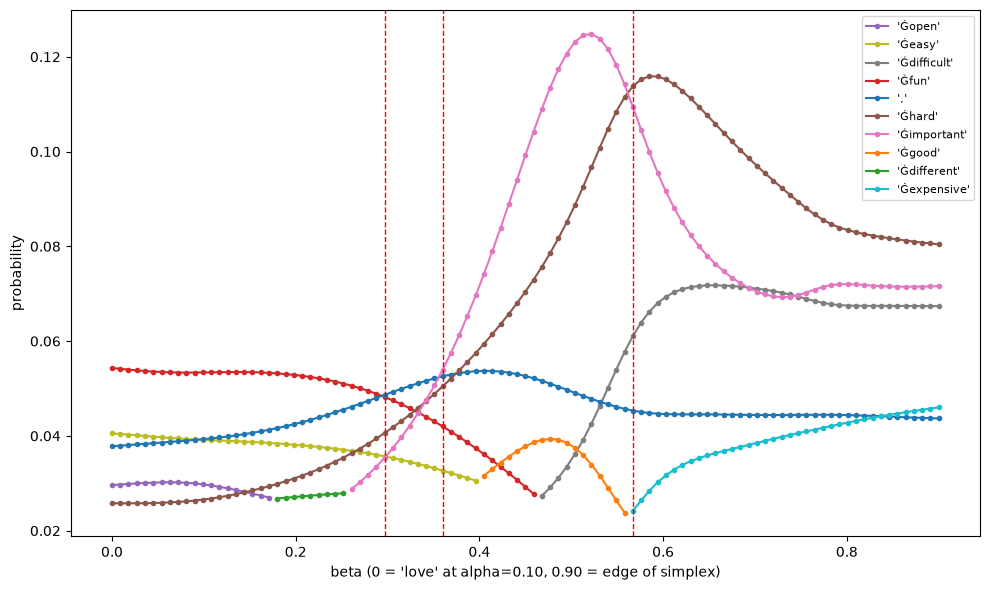

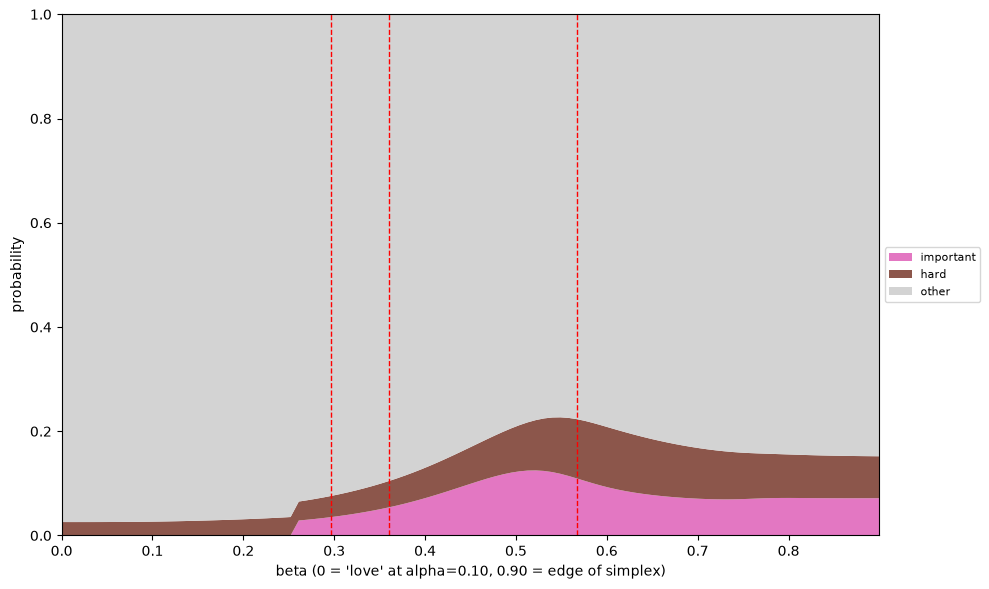

({0: torch.return_types.topk(
  values=tensor([0.0543, 0.0405, 0.0378, 0.0296, 0.0258]),
  indices=tensor([1257, 2562,   11, 1280, 1327])),
  1: torch.return_types.topk(
  values=tensor([0.0541, 0.0404, 0.0379, 0.0297, 0.0258]),
  indices=tensor([1257, 2562,   11, 1280, 1327])),
  2: torch.return_types.topk(
  values=tensor([0.0540, 0.0403, 0.0381, 0.0299, 0.0258]),
  indices=tensor([1257, 2562,   11, 1280, 1327])),
  3: torch.return_types.topk(
  values=tensor([0.0538, 0.0401, 0.0382, 0.0300, 0.0258]),
  indices=tensor([1257, 2562,   11, 1280, 1327])),
  4: torch.return_types.topk(
  values=tensor([0.0537, 0.0400, 0.0383, 0.0301, 0.0258]),
  indices=tensor([1257, 2562,   11, 1280, 1327])),
  5: torch.return_types.topk(
  values=tensor([0.0536, 0.0398, 0.0385, 0.0301, 0.0258]),
  indices=tensor([1257, 2562,   11, 1280, 1327])),
  6: torch.return_types.topk(
  values=tensor([0.0535, 0.0397, 0.0386, 0.0302, 0.0259]),
  indices=tensor([1257, 2562,   11, 1280, 1327])),
  7: torch.return_ty

In [21]:
drift_sentence_meaning_slice(
    "gpt2", "I love school because it's very", "hate", "question",
    changed_index=1, alpha=0.1,
)

## Points

In [27]:
def top5_at_point(alpha: float, beta: float, k: int = 5):
    # if alpha < 0 or beta < 0 or alpha + beta > 1:
    #     raise ValueError(f"(alpha={alpha}, beta={beta}) outside the simplex")
    embeds = base_embeds.clone()
    embeds[0, changed_index, :] = (
        (1 - alpha - beta) * original_vec
        + alpha * target_vec_1
        + beta * target_vec_2
    )
    with torch.no_grad():
        logits = model(inputs_embeds=embeds, attention_mask=attn).logits
    topk = torch.topk(torch.softmax(logits[0, -1, :], dim=-1), k)
    return [(tokenizer.decode(i).strip(), p.item())
            for p, i in zip(topk.values, topk.indices)]

In [28]:
top5_at_point(0.8, 0.8)

[('hard', 0.10400892049074173),
 ('difficult', 0.075444795191288),
 ('important', 0.05357924848794937),
 (',', 0.04490327835083008),
 ('expensive', 0.036498311907052994)]

In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def heatmap_word_probability(word, model_name="gpt2", phrase="I love school because it's very", target_word_1="hate", target_word_2="question",
                             changed_index=1, n_steps=26,
                             leading_space=True, mask_outside_simplex=True,
                             log_color=False, cmap="viridis"):
    """Heatmap of P(word) as the next token across the (alpha, beta) simplex.

    At each grid point the morphed embedding is the barycentric blend
        e = (1 - alpha - beta) * original + alpha * v1 + beta * v2
    alpha runs up the y axis toward target_word_1, beta across x toward target_word_2.
    Points with alpha + beta > 1 leave the simplex and are left blank.

    'word' is the token whose probability is measured. For GPT-2-style BPE the
    next token usually carries a leading space, so leading_space defaults to True.
    Multi-token words fall back to their first token, matching the rest of the code.
    Returns the (n_steps, n_steps) probability grid Z, with Z[i, j] at
    alpha = alphas[i], beta = betas[j]; masked cells are NaN.
    """
    tokenizer, model = _load(model_name)
    embedding_layer = model.get_input_embeddings()

    # token id whose probability we track
    text = (" " + word) if leading_space else word
    ids = tokenizer.encode(text)
    if len(ids) != 1:
        toks = tokenizer.convert_ids_to_tokens(ids)
        print(f"warning: {word!r} -> {len(ids)} tokens {toks}, using first")
    word_id = ids[0]
    word_tok = tokenizer.convert_ids_to_tokens([word_id])[0]

    inputs = tokenizer(phrase, return_tensors="pt")
    attn = inputs["attention_mask"]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    print("tokens:", list(enumerate(tokens)))
    print(f"measuring P({word_tok!r}), token id {word_id}")

    base_embeds = embedding_layer(inputs["input_ids"]).detach()
    original_vec = base_embeds[0, changed_index, :].clone()
    v1 = _word_embedding(tokenizer, embedding_layer, target_word_1)
    v2 = _word_embedding(tokenizer, embedding_layer, target_word_2)
    morph_word = tokenizer.decode([int(inputs["input_ids"][0][changed_index])]).strip()

    alphas = torch.linspace(0, 1, n_steps)
    betas = torch.linspace(0, 1, n_steps)
    Z = np.full((n_steps, n_steps), np.nan)  # Z[i, j]: i indexes alpha, j indexes beta

    for i, a in enumerate(alphas):
        a = float(a)
        for j, b in enumerate(betas):
            b = float(b)
            if mask_outside_simplex and a + b > 1.0 + 1e-9:
                continue
            embeds = base_embeds.clone()
            embeds[0, changed_index, :] = (1 - a - b) * original_vec + a * v1 + b * v2
            with torch.no_grad():
                logits = model(inputs_embeds=embeds, attention_mask=attn).logits
            Z[i, j] = torch.softmax(logits[0, -1, :].float(), dim=-1)[word_id].item()

    valid = np.isfinite(Z)
    if valid.any():
        k = np.nanargmax(np.where(valid, Z, -np.inf))
        bi, bj = np.unravel_index(k, Z.shape)
        print(f"max P({word_tok.strip()!r}) = {Z[bi, bj]:.4f} "
              f"at alpha={float(alphas[bi]):.2f}, beta={float(betas[bj]):.2f}")

    norm, plot_Z = None, Z
    if log_color:
        floor = Z[Z > 0].min() if np.any(Z > 0) else 1e-12
        plot_Z = np.where((Z <= 0) & valid, floor, Z)
        norm = LogNorm(vmin=floor, vmax=np.nanmax(plot_Z))

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(plot_Z, origin="lower", extent=[0, 1, 0, 1],
                   cmap=cmap, aspect="auto", interpolation="nearest",
                   norm=norm,
                   vmin=None if log_color else 0.0,
                   vmax=None if log_color else np.nanmax(Z))
    ax.plot([0, 1], [1, 0], color="white", linestyle="--", linewidth=1)  # simplex edge
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(f"beta (0 = {morph_word!r}, 1 = {target_word_2!r})")
    ax.set_ylabel(f"alpha (0 = {morph_word!r}, 1 = {target_word_1!r})")
    ax.set_title(f"P({word_tok.strip()!r}) as the next token")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"P({word_tok.strip()!r})")
    plt.tight_layout()
    plt.show()

    return Z

tokens: [(0, 'I'), (1, 'Ġlove'), (2, 'Ġschool'), (3, 'Ġbecause'), (4, 'Ġit'), (5, "'s"), (6, 'Ġvery')]
measuring P('Ġboring'), token id 14262
max P('Ġboring') = 0.1004 at alpha=0.84, beta=0.00


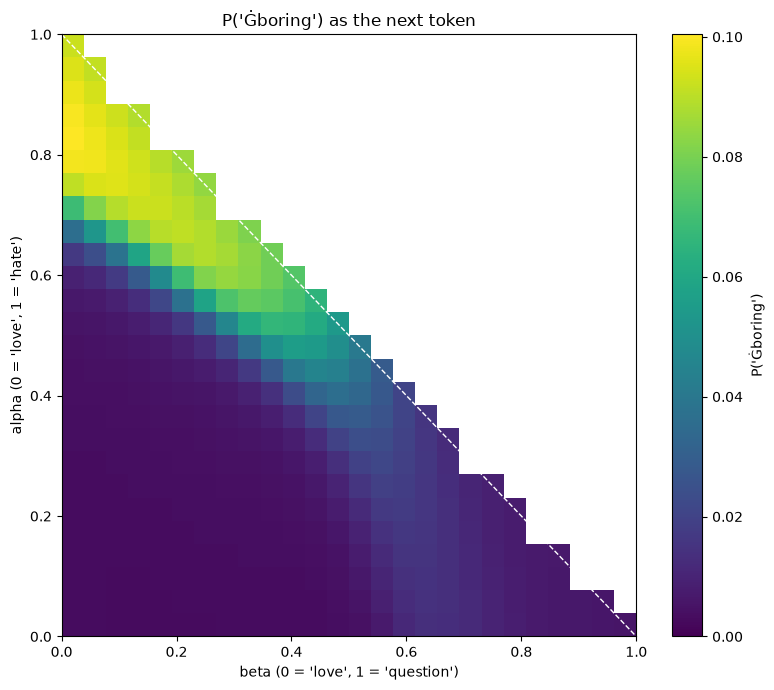

tokens: [(0, 'I'), (1, 'Ġlove'), (2, 'Ġschool'), (3, 'Ġbecause'), (4, 'Ġit'), (5, "'s"), (6, 'Ġvery')]
measuring P('Ġexciting'), token id 7895
max P('Ġexciting') = 0.0220 at alpha=0.00, beta=0.40


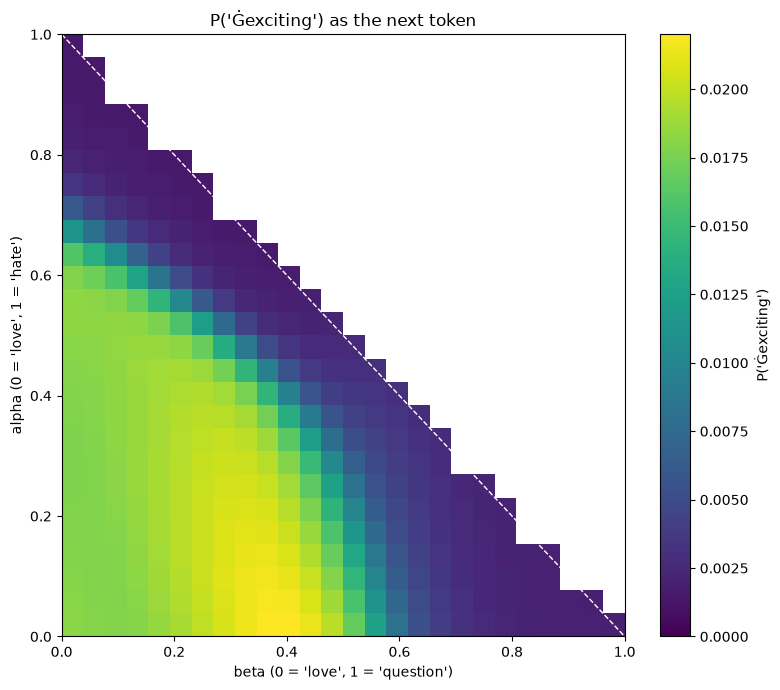

array([[0.01818212, 0.01798791, 0.01788875, 0.01802409, 0.01848236,
        0.01914944, 0.01990259, 0.02068704, 0.0214186 , 0.02193121,
        0.02200359, 0.02135669, 0.01970182, 0.01682706, 0.01259202,
        0.00816586, 0.00541127, 0.00397997, 0.00315325, 0.00263672,
        0.00233151, 0.00217044, 0.00208116, 0.00202555, 0.0019864 ,
        0.00195724],
       [0.01807788, 0.0179017 , 0.01787293, 0.01813414, 0.01867565,
        0.01935171, 0.02008325, 0.02082575, 0.02145331, 0.02180399,
        0.02166274, 0.02076095, 0.0188469 , 0.01568694, 0.01129889,
        0.00728218, 0.00499087, 0.00376969, 0.0030303 , 0.00255611,
        0.00228184, 0.00213522, 0.00205206, 0.00199792, 0.00195897,
               nan],
       [0.01798182, 0.01783894, 0.0178998 , 0.01826422, 0.01883714,
        0.01949885, 0.02020746, 0.02088656, 0.02140524, 0.02160023,
        0.02125651, 0.02011729, 0.0179341 , 0.01446513, 0.01001455,
        0.00650205, 0.00462406, 0.00357821, 0.00291317, 0.00247997,
      

In [34]:
heatmap_word_probability("boring")
heatmap_word_probability("exciting")